In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [3]:
df.job_posted_date = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## 🟩 Health Insurance Pie Chart (2.14.1) - Problem

Create a pie chart to show the proportion of job postings that mention health insurance for Data Analyst roles only:

* Create a new DataFrame called df_DA that only gets Data Analyst roles.
* Then count the number of data analyst roles that mention or not mention health insurance by using the job_health_insurance column.
* Plot this using plt.pie(), setting labels parameter to ['No', 'Yes'], startangle to 90, and format values to display similarly to 23.1%.
* Set the title to 'Proportion of Data Analyst Jobs Mentioning Health Insurance'.

In [20]:
df_DA = df.copy()[df['job_title_short'] == 'Data Analyst']

DA_insurance_counts = df_DA['job_health_insurance'].value_counts()

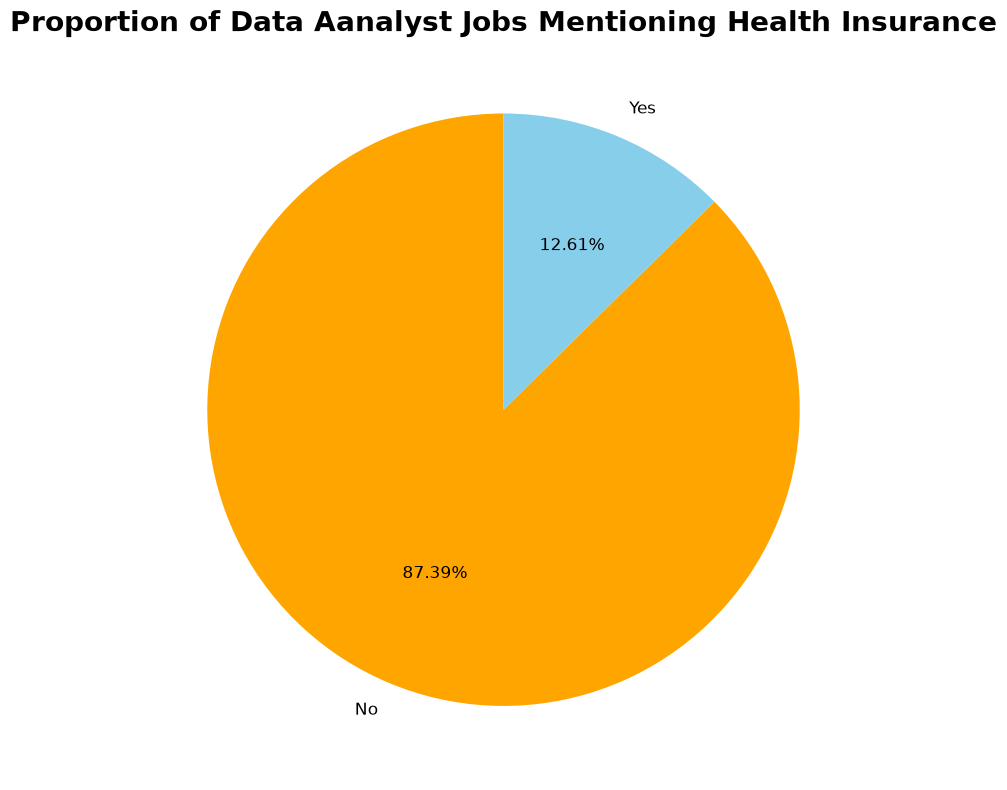

In [19]:
plt.figure(
    figsize = (8, 8)
            )

plt.pie(
    DA_insurance_counts
    , labels=(['No', 'Yes'])
    , autopct= '%1.2f%%'
    , startangle=90
    , colors= (['orange', 'skyblue'])
    , textprops={'fontsize': 12, 'color': 'black'}
        )

plt.title(
    'Proportion of Data Aanalyst Jobs Mentioning Health Insurance'
    , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.tight_layout()
plt.show()

## 🟨 Job Schedule Distribution (2.14.2) - Problem

* Create a pie chart showing the count of job postings per job schedule types (for only jobs that are either 'Full-time' and 'Part-time') in the DataFrame.
* Create a DataFrame to filter out these job_schedule_type called df_ft_pt.
* Plot this using plt.pie(), setting labels parameter to the index, startangle to 90, and format values to display similarly to 23.1%.
* Add a title 'Job Schedule Full-time vs. Part-time'.

In [32]:
df_FT_PT = df.copy()[(df['job_schedule_type'] == 'Full-time') | (df['job_schedule_type'] == 'Part-time')]
df_FT_PT_counts = df_FT_PT['job_schedule_type'].value_counts()

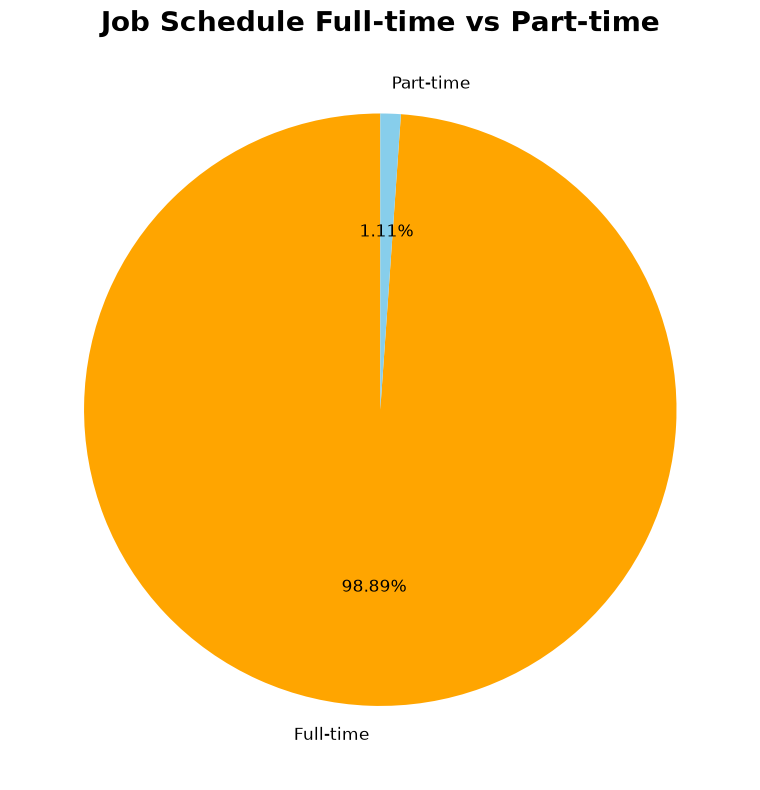

In [ ]:
plt.figure(
    figsize = (8, 8)
            )

plt.pie(
    df_FT_PT_counts
    , labels=['Full-time', 'Part-time']
    , autopct='%1.2f%%'
    , startangle=90
    , colors=(['orange', 'skyblue'])
    , textprops={'fontsize': 12, 'color': 'black'}
            )

plt.title(
    'Job Schedule Full-time vs. Part-time'
    , fontdict={'fontsize': 20, 'fontweight': 'bold'}
            )

plt.tight_layout()
plt.show()


## 🟥 Degree Mentioned Pie Chart (2.14.3) - Problem

* Create a pie chart to show the distribution of job postings that mention a degree in the job posting versus those that do not.
* Only get job postings located in the US, create a new DataFrame with this filtered data called df_US.
* Use the job_no_degree_mention column for this purpose.
* Customize the pie chart by exploding the slice for jobs that do not mention a degree. (Use the explode parameter set to (0, 0.1) inside of plt.pie())
* Set the chart title as 'Distribution of Jobs Mentioning Degrees for US Job Postings'.

In [44]:
df_US = df.copy()[df['job_country'] == 'United States']

df_US_degree_counts = df_US['job_no_degree_mention'].value_counts()

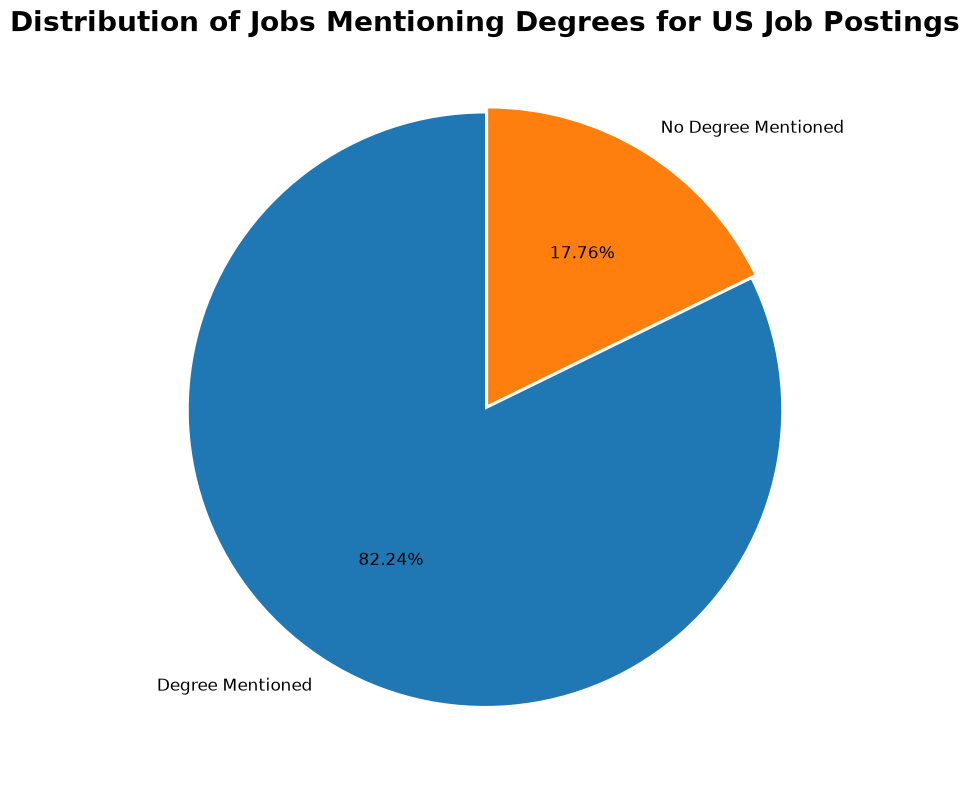

In [60]:
plt.figure(
    figsize=(8, 8)
            )

plt.pie(
    df_US_degree_counts
    , labels=(['Degree Mentioned', 'No Degree Mentioned'])
    , autopct='%1.2f%%'
    , startangle=90
    , explode=(0, 0.02)
    , textprops={'fontsize': 12, 'color': 'black'}
        )

plt.title(
    'Distribution of Jobs Mentioning Degrees for US Job Postings'
    , fontdict={'fontsize': 20, 'fontweight': 'bold'}
            )

plt.tight_layout()
plt.show()